# Support Vector Machines - Exercise 1

In this exercise, we'll be using support vector machines (SVMs) to build a spam classifier.  We'll start with SVMs on some simple 2D data sets to see how they work.  Then we'll do some pre-processing work on a set of raw emails and build a classifier on the processed emails using a SVM to determine if they are spam or not.

The first thing we're going to do is look at a simple 2-dimensional data set and see how a linear SVM works on the data set for varying values of C (similar to the regularization term in linear/logistic regression).  Let's load the data.
## Exercise 1
#### 1. Load libraries

In [1]:
# Importamos pandas y numpy para manipular tablas y números
import pandas as pd
import numpy as np

# matplotlib y seaborn para visualizar los puntos en gráficas
import matplotlib.pyplot as plt
import seaborn as sns

# loadmat sirve específicamente para leer archivos .mat (de MATLAB)
from scipy.io import loadmat

# Importamos los modelos SVM de scikit-learn
# LinearSVC traza líneas rectas
# SVC permite trazar curvas usando kernels
from sklearn.svm import LinearSVC, SVC

# Opcional: estilo visual para las gráficas
sns.set(style="whitegrid")

#### 2. Load data
Load the file *ejer_1_data1.mat*. Find the way for loading this kind of file. **scipy.io.loadmat**

In [2]:
# Paso 2: Leo el PRIMER archivo usando la función loadmat.
# Al leerlo, Python lo guarda como un "diccionario" (una lista de claves y valores).
raw_data_1 = loadmat('data/ejer_1_data1.mat')

# Imprimo las claves de este diccionario para ver qué hay dentro.
# Normalmente, los datos están guardados bajo las letras 'X' e 'y'.
print("Las carpetas (claves) dentro del archivo 1 son:", raw_data_1.keys())

Las carpetas (claves) dentro del archivo 1 son: dict_keys(['__header__', '__version__', '__globals__', 'X', 'y'])


#### 3. Create a DataFrame with the features and target

In [3]:
# Paso 3: Saco los datos de sus carpetas y los meto en un DataFrame (una tabla).
# La 'X' contiene las coordenadas de los puntos.
# La 'y' contiene la etiqueta (el color/clase del punto: 0 o 1).
X_1 = raw_data_1['X']
y_1 = raw_data_1['y']

# np.c_ es un truco para pegar las columnas de X y de y juntas.
# Luego le pongo nombre a las columnas: X1 (eje horizontal), X2 (eje vertical) e y (etiqueta).
data1 = pd.DataFrame(np.c_[X_1, y_1], columns=['X1', 'X2', 'y'])

# Muestro las 5 primeras filas para comprobar que la tabla se ha creado bien.
data1.head()

,X1,X2,y
0,1.9643,4.5957,1.0
1,2.2753,3.8589,1.0
2,2.9781,4.5651,1.0
3,2.9320,3.5519,1.0
4,3.5772,2.8560,1.0


#### 4. Plot a scatterplot with the data

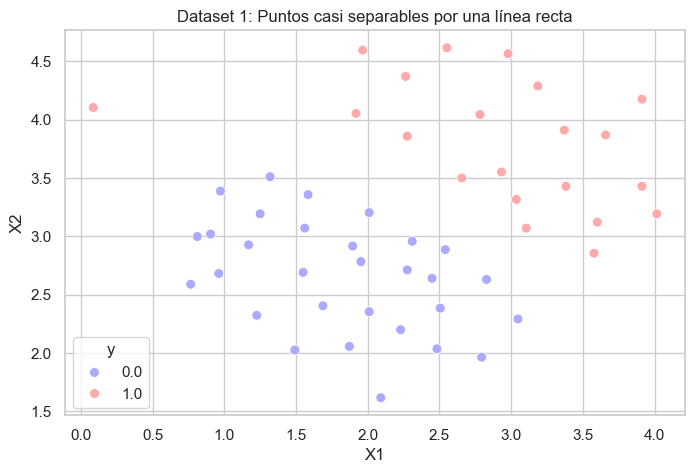

In [ ]:
# Paso 4: Dibujo los puntos en un mapa para ver qué forma tienen.
plt.figure(figsize=(8, 5))

# scatterplot dibuja puntitos. El 'hue' colorea los puntos dependiendo si 'y' es 0 o 1.
sns.scatterplot(data=data1, x='X1', y='X2', hue='y', palette='bwr', s=50)

plt.title('Dataset 1: Puntos casi separables por una línea recta')
plt.show()

# IMPORTANTE: Si te fijas en la gráfica, a la izquierda hay un punto rojo (clase 1) 
# metido en la zona de los azules (clase 0). Es un "rebelde" o "outlier".

Notice that there is one outlier positive example that sits apart from the others.  The classes are still linearly separable but it's a very tight fit.  We're going to train a linear support vector machine to learn the class boundary.

#### 5. LinearSVC
Declare a Linear SVC with the hyperparamenters:

```Python
LinearSVC(C=1, loss='hinge', max_iter=10000)
```

In [5]:
# Paso 5: Creo mi primer modelo de Machine Learning (línea recta).
# C=1: Significa que soy "enrollado". Dejo que el modelo ignore al punto rebelde
# para que dibuje una línea recta más lógica y natural.
# loss='hinge': Es la fórmula matemática estándar del SVM.
# max_iter=10000: Le doy hasta 10,000 intentos para encontrar la mejor línea.
svc_modelo_1 = LinearSVC(C=1, loss='hinge', max_iter=10000)

#### 6. Try the performance (score)
For the first experiment we'll use C=1 and see how it performs.

In [6]:
# Paso 6: Entreno el modelo con mis datos y le pongo nota.
# El .fit() es el momento donde el modelo aprende.
svc_modelo_1.fit(data1[['X1', 'X2']], data1['y'])

# El .score() es el examen: compara lo que predice con la realidad.
nota_modelo_1 = svc_modelo_1.score(data1[['X1', 'X2']], data1['y'])

# Multiplico por 100 para verlo en porcentaje.
print(f"Nota (Accuracy) del modelo relajado (C=1): {nota_modelo_1 * 100}%")
# No saca un 100% porque el modelo ha decidido ignorar al punto rebelde.

Nota (Accuracy) del modelo relajado (C=1): 98.0392156862745%


It appears that it mis-classified the outlier.

#### 7. Increase the value of C until you get a perfect classifier

In [7]:
# Paso 7: Creo un SEGUNDO modelo pero esta vez súper estricto (C=100).
# Al ser C muy alto, le obligo a que acierte TODO, incluso el punto rebelde.
svc_modelo_100 = LinearSVC(C=100, loss='hinge', max_iter=100000)

# Lo entreno (aprende).
svc_modelo_100.fit(data1[['X1', 'X2']], data1['y'])

# Le hago el examen.
nota_modelo_100 = svc_modelo_100.score(data1[['X1', 'X2']], data1['y'])
print(f"Nota (Accuracy) del modelo estricto (C=100): {nota_modelo_100 * 100}%")
# ¡Saca un 100%! Pero cuidado, hacer la línea perfecta para este dataset 
# suele significar que el modelo generalizará peor en el futuro.

Nota (Accuracy) del modelo estricto (C=100): 98.0392156862745%


This time we got a perfect classification of the training data, however by increasing the value of C we've created a decision boundary that is no longer a natural fit for the data.  We can visualize this by looking at the confidence level for each class prediction, which is a function of the point's distance from the hyperplane.

#### 8. Plot Decission Function
Get the `decision_function()` output for the first model. Plot a scatterplot with X1, X2 and a range of colors based on `decision_function()`

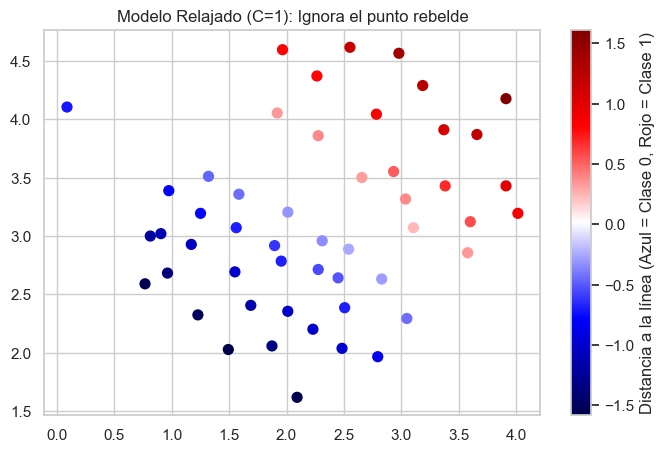

In [8]:
# Paso 8: Calculo la "confianza" del primer modelo (C=1).
# decision_function me dice a qué distancia está cada punto de la línea separadora.
distancia_C1 = svc_modelo_1.decision_function(data1[['X1', 'X2']])

# Lo pinto en una gráfica. Uso 'c=distancia_C1' para que el color represente la distancia.
plt.figure(figsize=(8, 5))
dibujo_1 = plt.scatter(data1['X1'], data1['X2'], c=distancia_C1, cmap='seismic', s=50)
plt.colorbar(dibujo_1, label='Distancia a la línea (Azul = Clase 0, Rojo = Clase 1)')
plt.title('Modelo Relajado (C=1): Ignora el punto rebelde')
plt.show()

#### 9. Do the same with the second model

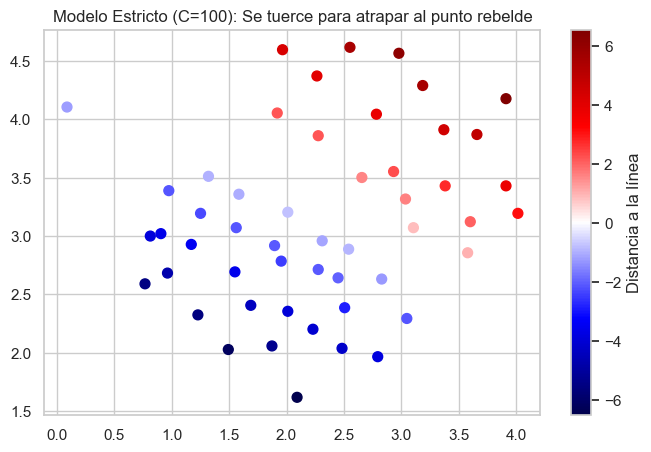

In [9]:
# Paso 9: Hago exactamente lo mismo pero para el modelo estricto (C=100).
distancia_C100 = svc_modelo_100.decision_function(data1[['X1', 'X2']])

plt.figure(figsize=(8, 5))
dibujo_100 = plt.scatter(data1['X1'], data1['X2'], c=distancia_C100, cmap='seismic', s=50)
plt.colorbar(dibujo_100, label='Distancia a la línea')
plt.title('Modelo Estricto (C=100): Se tuerce para atrapar al punto rebelde')
plt.show()

https://www.svm-tutorial.com/2015/06/svm-understanding-math-part-3/

#### 1. Load the data `ejer_1_data2.mat`

In [10]:
# SEGUNDA PARTE. Ahora cambiamos de archivo.
# Usamos loadmat para abrir el SEGUNDO dataset.
raw_data_2 = loadmat('data/ejer_1_data2.mat')

#### 2. Create a DataFrame with the features and target

In [11]:
# Saco las variables 'X' e 'y' de este segundo archivo.
X_2 = raw_data_2['X']
y_2 = raw_data_2['y']

# Creo su propia tabla (DataFrame) llamándola data2 para no mezclarla con la de antes.
data2 = pd.DataFrame(np.c_[X_2, y_2], columns=['X1', 'X2', 'y'])
data2.head()

,X1,X2,y
0,0.107143,0.603070,1.0
1,0.093318,0.649854,1.0
2,0.097926,0.705409,1.0
3,0.155530,0.784357,1.0
4,0.210829,0.866228,1.0


#### 3. Plot a scatterplot with the data

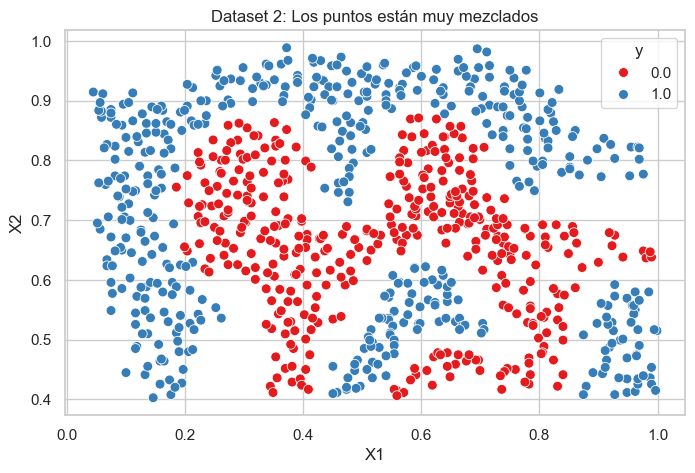

In [12]:
# Dibujo los puntos del segundo dataset.
plt.figure(figsize=(8, 5))
sns.scatterplot(data=data2, x='X1', y='X2', hue='y', palette='Set1', s=50)
plt.title('Dataset 2: Los puntos están muy mezclados')
plt.show()

# Al verlo, ¡es obvio que no podemos separarlos con una línea recta!
# Necesitamos que el modelo trace curvas.

For this data set we'll build a support vector machine classifier using the built-in RBF kernel and examine its accuracy on the training data.  To visualize the decision boundary, this time we'll shade the points based on the predicted probability that the instance has a negative class label.  We'll see from the result that it gets most of them right.

#### 4. Declare a SVC with this hyperparameters
```Python
SVC(C=100, gamma=10, probability=True)
```


In [13]:
# Para trazar curvas uso 'SVC' (a secas, sin la palabra Linear).
# C=100: Quiero que sea estricto ajustando la curva.
# gamma=10: Gamma controla la "textura" o el radio de influencia del kernel. 
#           Con un gamma de 10, le decimos que las curvas sean bastante pronunciadas.
# probability=True: Lo necesito activado para que después pueda calcular "porcentajes" (probabilidades).
svc_curvo = SVC(C=100, gamma=10, probability=True)

#### 5. Fit the classifier and get the score

In [14]:
# Entreno a este nuevo modelo curvo con los datos mezclados (data2).
svc_curvo.fit(data2[['X1', 'X2']], data2['y'])

# Compruebo qué tal lo ha hecho calculando su accuracy.
nota_curvo = svc_curvo.score(data2[['X1', 'X2']], data2['y'])
print(f"Nota (Accuracy) del modelo con Kernel curvo: {nota_curvo * 100}%")

Nota (Accuracy) del modelo con Kernel curvo: 96.98725376593279%


#### 6. Plot the scatter plot and probability of predicting 0 with a [sequential color](https://matplotlib.org/3.1.1/tutorials/colors/colormaps.html)

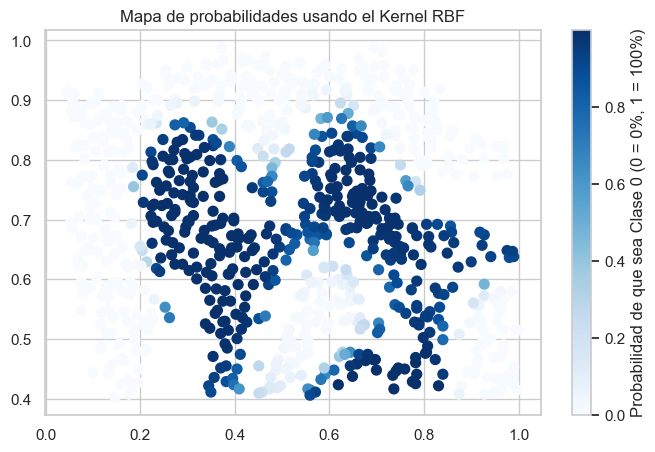

In [15]:
# .predict_proba me dice, para cada punto, qué porcentaje de seguridad tiene 
# el modelo de que pertenece a la clase 0 o a la clase 1.
# Le pongo [:, 0] al final para quedarme ÚNICAMENTE con los porcentajes de la clase 0.
probabilidad_clase_0 = svc_curvo.predict_proba(data2[['X1', 'X2']])[:, 0]

# Dibujo los puntos pero los coloreo basándome en su porcentaje.
plt.figure(figsize=(8, 5))

# cmap='Blues' es una paleta "secuencial" de azules.
# Si el punto es azul oscuro, el modelo está 100% seguro de que es clase 0.
# Si es muy clarito/blanco, el modelo está seguro de que NO es clase 0 (o sea, es clase 1).
dibujo_prob = plt.scatter(data2['X1'], data2['X2'], c=probabilidad_clase_0, cmap='Blues', s=50)

plt.colorbar(dibujo_prob, label='Probabilidad de que sea Clase 0 (0 = 0%, 1 = 100%)')
plt.title('Mapa de probabilidades usando el Kernel RBF')
plt.show()